In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your specific dataset
df = pd.read_csv('/home/sayantan/Documents/supply_chain_PROJECT/data/DataCoSupplyChainDataset.csv', encoding='iso-8859-1')

# Select only the columns we need for the supply chain project to keep it clean
cols_to_keep = [
    'Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Delivery Status', 'Late_delivery_risk', 'Category Name',
    'Customer Segment', 'Order City', 'Order Country', 'Order Region',
    'order date (DateOrders)', 'Order Item Quantity', 'Sales',
    'Order Profit Per Order', 'Product Name', 'Shipping Mode'
]
df = df[cols_to_keep]

# Convert the order date to a true datetime object
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

df.head()

Matplotlib is building the font cache; this may take a moment.


,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Name,Customer Segment,Order City,Order Country,Order Region,order date (DateOrders),Order Item Quantity,Sales,Order Profit Per Order,Product Name,Shipping Mode
0,DEBIT,3,4,Advance shipping,0,Sporting Goods,Consumer,Bekasi,Indonesia,Southeast Asia,2018-01-31 22:56:00,1,327.75,91.250000,Smart watch,Standard Class
1,TRANSFER,5,4,Late delivery,1,Sporting Goods,Consumer,Bikaner,India,South Asia,2018-01-13 12:27:00,1,327.75,-249.089996,Smart watch,Standard Class
2,CASH,4,4,Shipping on time,0,Sporting Goods,Consumer,Bikaner,India,South Asia,2018-01-13 12:06:00,1,327.75,-247.779999,Smart watch,Standard Class
3,DEBIT,3,4,Advance shipping,0,Sporting Goods,Home Office,Townsville,Australia,Oceania,2018-01-13 11:45:00,1,327.75,22.860001,Smart watch,Standard Class
4,PAYMENT,2,4,Advance shipping,0,Sporting Goods,Corporate,Townsville,Australia,Oceania,2018-01-13 11:24:00,1,327.75,134.210007,Smart watch,Standard Class


Current Supply Chain On-Time Rate: 42.72%


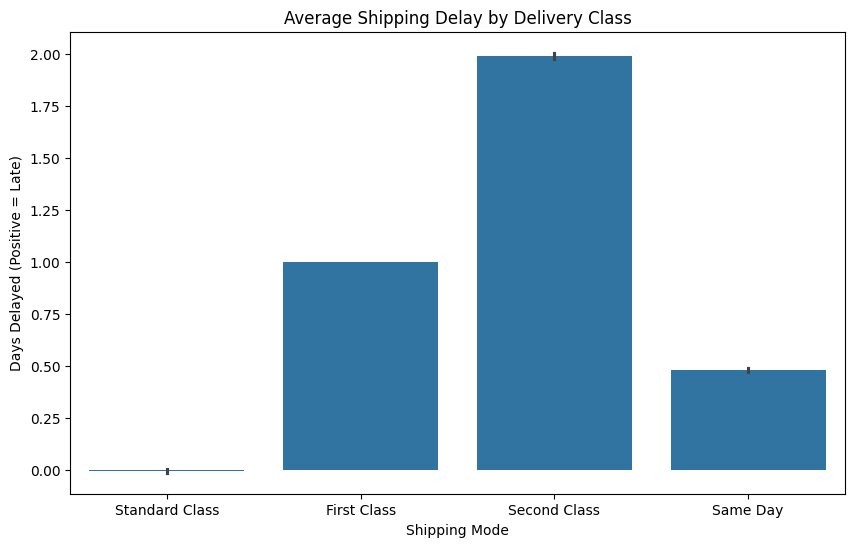

In [8]:
# Calculate the 'Shipping Delay' (Real days minus Scheduled days)
df['Shipping_Gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# A 'Successful' delivery is when the gap is 0 or less (arrived on time or early)
df['Is_On_Time'] = df['Shipping_Gap'] <= 0

# Calculate the Global On-Time Delivery Rate
on_time_rate = df['Is_On_Time'].mean() * 100
print(f"Current Supply Chain On-Time Rate: {on_time_rate:.2f}%")

# Visualize which Shipping Modes are the most unreliable
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Shipping Mode', y='Shipping_Gap', estimator=np.mean)
plt.title('Average Shipping Delay by Delivery Class')
plt.ylabel('Days Delayed (Positive = Late)')
plt.show()

In [9]:
# Group by Region to find where late deliveries happen most
region_risk = df.groupby('Order Region').agg(
    Total_Orders=('Sales', 'count'),
    Late_Risk_Percentage=('Late_delivery_risk', 'mean'),
    Avg_Profit=('Order Profit Per Order', 'mean')
).reset_index()

# Sort by the highest risk
region_risk = region_risk.sort_values(by='Late_Risk_Percentage', ascending=False)

# Display the Top 5 Most At-Risk Regions
region_risk.head(5)

,Order Region,Total_Orders,Late_Risk_Percentage,Avg_Profit
2,Central Africa,1677,0.579606,19.944705
13,South Asia,7731,0.562670,21.433696
5,East Africa,1852,0.559395,23.308709
22,Western Europe,27109,0.558486,23.071529
14,South of USA,4045,0.557726,21.783654


In [11]:
# 1. Identify the average daily demand for each product
# NOTE: We use the exact column name 'Product Name' and 'order date (DateOrders)'
daily_demand = df.groupby(['Product Name', 'order date (DateOrders)'])['Order Item Quantity'].sum().reset_index()
avg_demand = daily_demand.groupby('Product Name')['Order Item Quantity'].mean()

# 2. Identify the variability (Standard Deviation) of the shipping time
# NOTE: Using 'Days for shipping (real)' as our Lead Time
lead_time_variability = df.groupby('Product Name')['Days for shipping (real)'].std().fillna(0)

# 3. Calculate Safety Stock (using 1.65 for a 95% service level)
safety_stock = (1.65 * lead_time_variability * avg_demand).round(0)

# Create the final summary table
inventory_plan = pd.DataFrame({
    'Avg_Daily_Demand': avg_demand,
    'Lead_Time_Unreliability': lead_time_variability,
    'Recommended_Safety_Stock': safety_stock
}).sort_index()

inventory_plan.head(10)

,Avg_Daily_Demand,Lead_Time_Unreliability,Recommended_Safety_Stock
Product Name,,,
Adult dog supplies,1.000000,1.656224,3.0
Baby sweater,1.000000,1.712826,3.0
Bag Boy Beverage Holder,3.039568,1.553412,8.0
Bag Boy M330 Push Cart,3.014493,1.628942,8.0
Bowflex SelectTech 1090 Dumbbells,1.000000,1.433721,2.0
Bridgestone e6 Straight Distance NFL Carolina,3.012987,1.551763,8.0
Bridgestone e6 Straight Distance NFL San Dieg,2.932039,1.658065,8.0
Bridgestone e6 Straight Distance NFL Tennesse,3.144531,1.715678,9.0
Brooks Women's Ghost 6 Running Shoe,3.212121,1.570711,8.0


In [12]:
def simulate_regional_disruption(data, target_region, delay_days=5):
    sim_df = data.copy()
    
    # Identify orders in the affected region
    mask = sim_df['Order Region'] == target_region
    
    # Add the delay to the real shipping days
    sim_df.loc[mask, 'Days for shipping (real)'] += delay_days
    
    # Recalculate late delivery risk
    sim_df['New_Late_Risk'] = sim_df['Days for shipping (real)'] > sim_df['Days for shipment (scheduled)']
    
    old_risk = data[mask]['Late_delivery_risk'].mean() * 100
    new_risk = sim_df[mask]['New_Late_Risk'].mean() * 100
    
    print(f"Simulation Result for {target_region}:")
    print(f"Original Late Risk: {old_risk:.2f}%")
    print(f"Post-Disruption Risk: {new_risk:.2f}%")
    
    return sim_df

# Run the simulation for 'Central America'
disrupted_data = simulate_regional_disruption(df, 'Central America')

Simulation Result for Central America:
Original Late Risk: 54.75%
Post-Disruption Risk: 100.00%
